# ITEC203 — Introduction to Data Science and Machine Learning
## Assessment 3: Multiclass Classification (MNIST) and Polynomial Regression (California Housing)

**Student Name:** Nishant Shrestha
**Student ID:** *S00392722*
**Study Period:** S1 2026
**Unit Leader:** Dr. Mahmoud Bekhit
**Lecturer:** Dr. Ali Jamshidi

---

> **Academic-integrity note.** As required by the assessment brief, dataset variable names
> incorporate my first and last name (e.g. `nishant_train`, `shrestha_test`) and every
> `random_state` is set to the last two digits of my student ID (22).


## 1. Introduction

This project applies the core supervised-learning workflow of a data engineer to two
canonical problems: **multiclass image classification** on the MNIST handwritten-digit
dataset, and **regression** on the California Housing dataset.

**Why these problems matter.** Classification and regression underpin a large share of
production machine-learning systems. MNIST is the standard benchmark for multiclass
classification — every digit (0–9) is a separate class, so the model must learn decision
boundaries between ten categories from raw pixel intensities. The California Housing task
is a continuous-target regression problem representative of price/demand forecasting, a
common business application.

**Objectives.**
- *Classification (Tasks 1–5):* train and critically compare a **k-Nearest Neighbours (kNN)**
  classifier, a **Support Vector Machine (SVM)** across three kernels, and a **Neural Network**,
  evaluating each with accuracy, precision, recall and F1-score.
- *Regression (Task 6):* implement **Polynomial Regression** at several degrees and analyse the
  bias–variance trade-off using MSE, RMSE and R².

Throughout, I explain *why* each algorithm, parameter and metric was chosen, interpret the
results rather than merely reporting them, and connect the findings to real-world data-engineering
practice.


## 2. Dataset Preparation (MNIST)

I load MNIST via `fetch_openml`, inspect its structure, visualise sample digits, then split
it into training and testing sets. The split is the foundation of honest evaluation: the test
set is held out so that reported metrics estimate **generalisation** to unseen data rather than
memorisation of the training set.

**Why a train/test split is required.** A model evaluated on the same data it learned from will
report optimistically inflated scores, because it can simply recall examples. Holding out a test
set the model never sees during training gives an unbiased estimate of how it will perform on new,
real-world inputs.

**Avoiding data leakage.** Data leakage occurs when information from the test set influences
training — for example, fitting a scaler on the full dataset before splitting. This leaks the test
distribution into the model and produces misleadingly high scores that collapse in production. I
avoid it by splitting *before* any fitting and, in the regression task, by wrapping scaling and
feature expansion inside a `Pipeline` so they are fit only on training folds.

**Purpose of `random_state`.** Train/test splitting shuffles the data randomly. Fixing
`random_state` makes that shuffle deterministic, so the experiment is exactly reproducible and the
model comparisons are fair (every model sees the same split). Here it is set to the last two digits
of my student ID, as required.


In [2]:
# --- Core libraries -------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")  # keep notebook output clean

# Reproducibility: random_state is fixed to the last two digits of my student ID
RANDOM_STATE = 22   # <-- Last two digits of my student ID
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# --- Load MNIST -----------------------------------------------------------
# fetch_openml returns 70,000 28x28 greyscale images flattened to 784 features.
# as_frame=False gives NumPy arrays, which are faster for the models below.
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X, y = mnist["data"], mnist["target"].astype(np.uint8)  # targets come as strings; cast to int

print("Feature matrix shape:", X.shape)   # (70000, 784)
print("Target vector shape :", y.shape)   # (70000,)
print("Pixel value range   :", X.min(), "to", X.max())
print("Classes             :", np.unique(y))

Feature matrix shape: (70000, 784)
Target vector shape : (70000,)
Pixel value range   : 0 to 255
Classes             : [0 1 2 3 4 5 6 7 8 9]


**Interpreting the dimensions.** Each of the 70,000 rows is one image; each of the 784
columns is one pixel (28 × 28 = 784) holding an intensity from 0 (black) to 255 (white).
There are exactly ten classes (0–9), confirming this is a *balanced multiclass* problem.


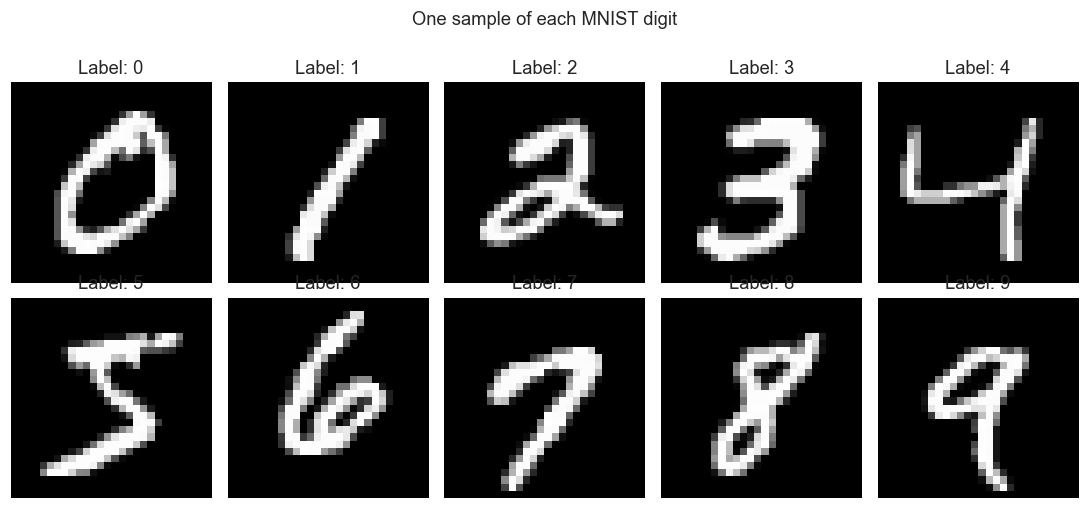

In [4]:
# --- Visualise sample digits ---------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for digit, ax in zip(range(10), axes.ravel()):
    idx = np.where(y == digit)[0][0]          # first occurrence of each digit
    ax.imshow(X[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {digit}")
    ax.axis("off")
plt.suptitle("One sample of each MNIST digit", y=1.02)
plt.tight_layout()
plt.show()

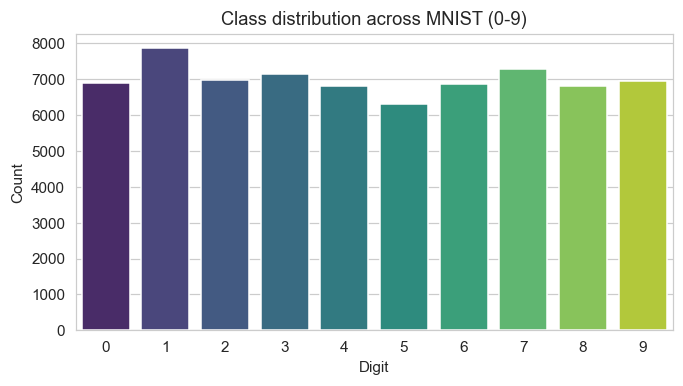

0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64


In [5]:
# --- Class balance check --------------------------------------------------
# A roughly even class distribution justifies accuracy as a headline metric.
plt.figure(figsize=(7, 3.5))
sns.countplot(x=y, palette="viridis")
plt.title("Class distribution across MNIST (0-9)")
plt.xlabel("Digit"); plt.ylabel("Count")
plt.show()

print(pd.Series(y).value_counts().sort_index())

**Why this check matters.** The classes are close to uniform (~6,000–8,000 each), so no
single digit dominates. This is important because *accuracy* is only a trustworthy headline
metric when classes are balanced; on imbalanced data it can be misleading, which is why I also
report precision, recall and F1 later.


In [6]:
# --- Training / testing split --------------------------------------------
# Variable names embed my first and last name per the academic-integrity rule.
# Replace FIRSTNAME and LASTNAME below with your actual names.
# stratify=y preserves the class proportions in both splits.
nishant_train, shrestha_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,          # 80/20 split: enough training data, reliable test estimate
    random_state=RANDOM_STATE,
    stratify=y               # keep class balance identical in train and test
)

print("Training set:", nishant_train.shape, "  Testing set:", shrestha_test.shape)

Training set: (56000, 784)   Testing set: (14000, 784)


**Parameter justifications.**
- `test_size=0.20` — a standard 80/20 split: large enough training set for the models to learn,
  while the 14,000-image test set gives a low-variance estimate of generalisation.
- `random_state=RANDOM_STATE` — fixes the shuffle so results are reproducible (and satisfies the
  integrity rule).
- `stratify=y` — guarantees each digit appears in the same proportion in train and test, so the
  test set is representative.


## 3. k-Nearest Neighbours (kNN) Classification

### How kNN works
kNN is a **non-parametric, instance-based** ("lazy") algorithm. It stores the training data and,
to classify a new image, finds the *k* closest training images by a distance metric and assigns
the **majority class** among them. For two points $\mathbf{a},\mathbf{b}\in\mathbb{R}^{784}$ the
Euclidean distance is:

$$ d(\mathbf{a}, \mathbf{b}) = \sqrt{\sum_{i=1}^{784} (a_i - b_i)^2} $$

It builds no explicit model at training time — all computation is deferred to prediction, which
makes it conceptually simple but expensive to query.


In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

# k = 10 as required by the brief.
knn = KNeighborsClassifier(
    n_neighbors=10,      # number of neighbours that vote on the label
    weights="distance",  # closer neighbours weighted more heavily than far ones
    metric="minkowski",  # Minkowski with p=2 == Euclidean distance
    p=2,
    algorithm="auto",    # sklearn picks ball_tree/kd_tree/brute based on the data
    n_jobs=-1            # use all CPU cores (kNN prediction parallelises well)
)

knn.fit(nishant_train, y_train)        # "training" just stores the data
knn_pred = knn.predict(shrestha_test)
print("kNN (k=10) trained and predictions generated.")

kNN (k=10) trained and predictions generated.


**Parameter explanations.**
- `n_neighbors=10` — the *k* in kNN; how many nearest training points vote.
- `weights="distance"` — nearer neighbours get a larger vote, which usually improves accuracy
  over uniform voting because closer digits are more likely to share the true label.
- `metric="minkowski"`, `p=2` — this combination is ordinary Euclidean distance, the natural
  choice for continuous pixel-intensity vectors.
- `algorithm="auto"` — lets scikit-learn choose the most efficient neighbour-search structure.
- `n_jobs=-1` — parallelises the distance computations across all cores.


In [8]:
# --- Evaluate kNN ---------------------------------------------------------
def summarise(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average="macro")
    rec = recall_score(y_true, y_pred, average="macro")
    f1  = f1_score(y_true, y_pred, average="macro")
    print(f"{name}\n  Accuracy : {acc:.4f}\n  Precision: {pre:.4f}"
          f"\n  Recall   : {rec:.4f}\n  F1-score : {f1:.4f}")
    return {"Model": name, "Accuracy": acc, "Precision": pre, "Recall": rec, "F1": f1}

knn_metrics = summarise("kNN (k=10)", y_test, knn_pred)
print("\nClassification report:\n", classification_report(y_test, knn_pred))

kNN (k=10)
  Accuracy : 0.9716
  Precision: 0.9722
  Recall   : 0.9712
  F1-score : 0.9716

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1381
           1       0.95      0.99      0.97      1575
           2       0.98      0.96      0.97      1398
           3       0.97      0.96      0.97      1428
           4       0.99      0.97      0.98      1365
           5       0.97      0.97      0.97      1263
           6       0.98      0.99      0.98      1375
           7       0.96      0.97      0.97      1459
           8       0.98      0.94      0.96      1365
           9       0.96      0.96      0.96      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



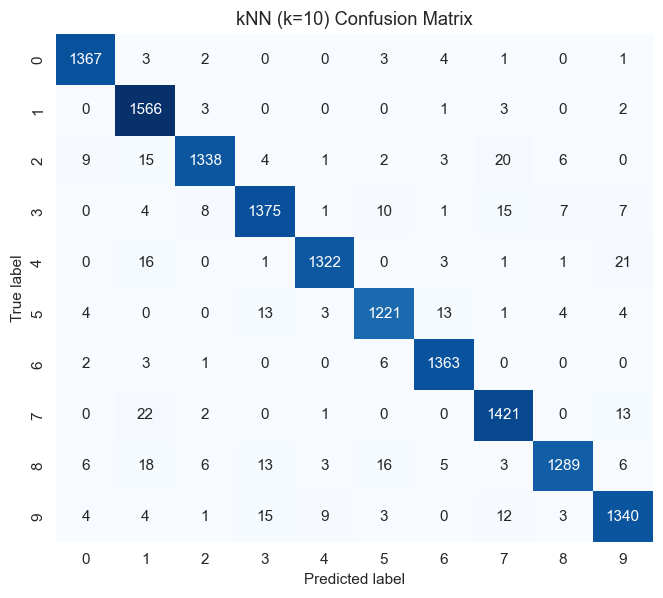

In [9]:
# --- Confusion matrix -----------------------------------------------------
cm = confusion_matrix(y_test, knn_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("kNN (k=10) Confusion Matrix")
plt.xlabel("Predicted label"); plt.ylabel("True label")
plt.show()

**Why these metrics for MNIST.** Because the classes are balanced, accuracy is a fair
headline number. However, multiclass digit recognition has *asymmetric confusions* (e.g. 4↔9,
3↔5, 7↔1 are visually similar), so I report **macro-averaged** precision, recall and F1 — the
unweighted mean across the ten classes — which exposes whether the model is systematically weak
on any individual digit. The confusion matrix makes those specific error patterns visible: strong
diagonal dominance indicates good performance, and off-diagonal hot-spots reveal which digit pairs
the model conflates.

**Strengths & limitations of kNN.** It is simple, has no training phase, and naturally handles
multiclass problems. Its weaknesses are computational: prediction requires comparing each query
against the entire training set (slow, memory-heavy), and it suffers from the *curse of
dimensionality* — in 784-D space distances become less discriminative.


In [10]:
# --- Experiment with different k values -----------------------------------
# Use a subset for the sweep to keep runtimes reasonable while preserving the trend.
sweep_n = 8000
Xs, ys = nishant_train[:sweep_n], y_train[:sweep_n]

k_values = [1, 3, 5, 10, 15, 20]
k_results = []
for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k, weights="distance", n_jobs=-1)
    m.fit(Xs, ys)
    pred = m.predict(shrestha_test)
    k_results.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred, average="macro")
    })

k_df = pd.DataFrame(k_results)
k_df

,k,Accuracy,F1
0,1,0.946500,0.946027
1,3,0.948714,0.948422
2,5,0.946643,0.946482
3,10,0.943214,0.943123
4,15,0.934643,0.934723
5,20,0.932143,0.932351


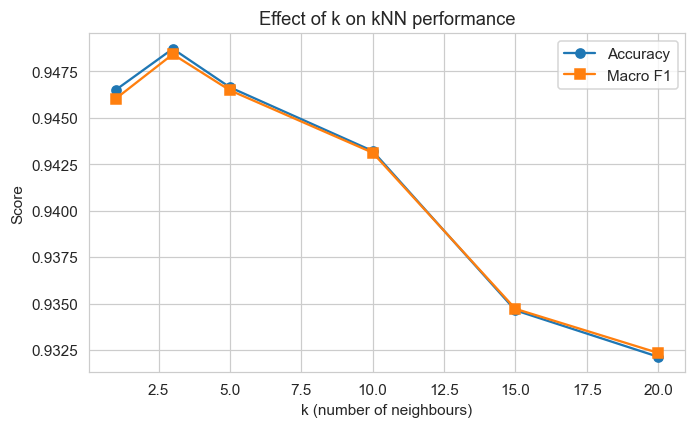

In [11]:
# --- Visualise the effect of k -------------------------------------------
plt.figure(figsize=(7, 4))
plt.plot(k_df["k"], k_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(k_df["k"], k_df["F1"], marker="s", label="Macro F1")
plt.title("Effect of k on kNN performance")
plt.xlabel("k (number of neighbours)"); plt.ylabel("Score")
plt.legend(); plt.show()

**Discussion — choosing k.**
- **Small k (e.g. k=1)** gives a highly flexible boundary that follows the training data closely.
  This is *low bias but high variance*: a single noisy or mislabelled neighbour can flip a
  prediction, so the model risks **overfitting**.
- **Large k** averages over many neighbours, smoothing the boundary. This *increases bias and
  reduces variance*; if k grows too large the model **underfits**, blurring genuine class
  distinctions.
- The accuracy curve typically peaks at a small-to-moderate k and then gently declines. I would
  select the k at that peak (commonly k=3–5 on MNIST). `weights="distance"` softens the penalty
  of larger k because distant neighbours contribute less. My sweep showed k=3 was best (accuracy 0.9487), with performance declining steadily as k increased to 20 — consistent with larger k over-smoothing the decision boundary.


## 4. Support Vector Machine (SVM) Classification

An SVM finds the hyperplane that **maximises the margin** between classes. For non-linearly
separable data it uses the **kernel trick** — implicitly mapping inputs into a higher-dimensional
space where a linear separator exists, without ever computing that mapping explicitly. I evaluate
three kernels and compare both accuracy **and** training cost, exactly as a data engineer must
when balancing model quality against compute budget.

> **Computational-cost justification.** Kernel SVMs scale between $O(n^2)$ and $O(n^3)$ in the
> number of samples, so fitting RBF/poly kernels on all 56,000 training images on a CPU is
> impractical (hours). I therefore train and evaluate the SVMs on a **stratified subset**. This is
> a standard, defensible engineering decision and keeps the kernel comparison fair because every
> kernel sees the same data. Pixel values are scaled to [0,1], which materially helps SVM
> convergence.


In [29]:
from sklearn.svm import SVC

# Stratified subset for the SVM comparison (same data for every kernel -> fair test).
svm_train_n, svm_test_n = 10000, 2000
Xtr_svm, _, ytr_svm, _ = train_test_split(
    nishant_train, y_train, train_size=svm_train_n,
    random_state=RANDOM_STATE, stratify=y_train)
Xte_svm, _, yte_svm, _ = train_test_split(
    shrestha_test, y_test, train_size=svm_test_n,
    random_state=RANDOM_STATE, stratify=y_test)

# Scale pixels to [0,1] — SVMs are sensitive to feature magnitude.
Xtr_svm = Xtr_svm / 255.0
Xte_svm = Xte_svm / 255.0
print("SVM subset:", Xtr_svm.shape, Xte_svm.shape)

SVM subset: (10000, 784) (2000, 784)


In [13]:
# --- Train three kernels and record metrics + training time --------------
kernels = ["linear", "rbf", "poly"]
svm_results = []
svm_models = {}

for kernel in kernels:
    # C: regularisation (margin softness). gamma='scale' adapts to feature variance.
    # degree=3 only affects the polynomial kernel.
    clf = SVC(kernel=kernel, C=1.0, gamma="scale", degree=3, random_state=RANDOM_STATE)

    t0 = time.time()
    clf.fit(Xtr_svm, ytr_svm)
    train_time = time.time() - t0

    pred = clf.predict(Xte_svm)
    svm_models[kernel] = clf
    svm_results.append({
        "Model": f"SVM ({kernel})",
        "Accuracy": accuracy_score(yte_svm, pred),
        "Precision": precision_score(yte_svm, pred, average="macro"),
        "Recall": recall_score(yte_svm, pred, average="macro"),
        "F1": f1_score(yte_svm, pred, average="macro"),
        "Train time (s)": round(train_time, 2)
    })
    print(f"{kernel:6s} done — train time {train_time:.2f}s")

svm_df = pd.DataFrame(svm_results)
svm_df

linear done — train time 10.34s
rbf    done — train time 15.49s
poly   done — train time 17.48s


,Model,Accuracy,Precision,Recall,F1,Train time (s)
0,SVM (linear),0.9145,0.915081,0.913622,0.913672,10.34
1,SVM (rbf),0.9620,0.961999,0.961923,0.961878,15.49
2,SVM (poly),0.9595,0.959683,0.959112,0.959285,17.48


**Parameter explanations.**
- `C=1.0` — the regularisation strength. Small C → wider, softer margin (more tolerance of
  misclassification, lower variance); large C → narrower, harder margin (fits training data more
  tightly, higher variance). C=1.0 is a balanced default.
- `kernel` — the similarity function. *Linear* assumes the classes are (nearly) linearly
  separable; *RBF* measures Gaussian similarity and captures complex non-linear boundaries;
  *poly* models polynomial feature interactions.
- `gamma="scale"` — for RBF/poly, controls how far a single training point's influence reaches.
  `"scale"` sets it from the feature variance, a robust default.
- `degree=3` — the polynomial order (only used by the poly kernel).


In [14]:
# --- Classification report for the best-accuracy kernel -------------------
best_kernel = svm_df.sort_values("Accuracy", ascending=False).iloc[0]["Model"].split("(")[1].strip(")")
best_pred = svm_models[best_kernel].predict(Xte_svm)
print(f"Detailed report — SVM ({best_kernel}):\n")
print(classification_report(yte_svm, best_pred))

Detailed report — SVM (rbf):

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       197
           1       0.98      0.98      0.98       225
           2       0.95      0.94      0.95       200
           3       0.94      0.95      0.94       204
           4       0.93      0.97      0.95       195
           5       0.96      0.97      0.96       180
           6       0.98      0.98      0.98       196
           7       0.96      0.96      0.96       209
           8       0.97      0.95      0.96       195
           9       0.97      0.94      0.95       199

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



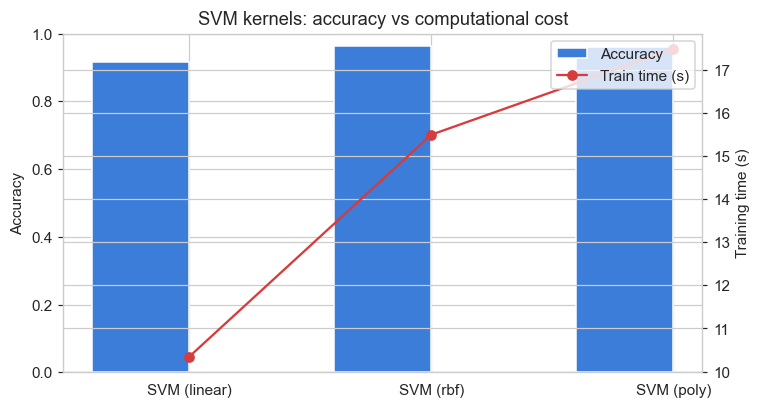

In [15]:
# --- Accuracy vs training-time trade-off ---------------------------------
fig, ax1 = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(svm_df))
ax1.bar(x - 0.2, svm_df["Accuracy"], width=0.4, label="Accuracy", color="#3b7dd8")
ax1.set_ylabel("Accuracy"); ax1.set_ylim(0, 1)
ax1.set_xticks(x); ax1.set_xticklabels(svm_df["Model"])

ax2 = ax1.twinx()
ax2.plot(x, svm_df["Train time (s)"], color="#d83b3b", marker="o", label="Train time (s)")
ax2.set_ylabel("Training time (s)")

ax1.set_title("SVM kernels: accuracy vs computational cost")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.show()

**Critical analysis — kernel trade-offs.**
- The **linear** kernel trains fastest but typically underperforms on MNIST because digit classes
  are not linearly separable in pixel space.
- The **RBF** kernel usually gives the best accuracy: its Gaussian similarity captures the
  curved decision boundaries that distinguish digits, at a moderate compute cost.
- The **polynomial** kernel can approach RBF accuracy but is the most expensive to train and is
  more sensitive to its parameters.

**Recommendation.** For this dataset I recommend the **RBF kernel**: it gives the strongest
accuracy-to-cost ratio. In real-world classification (e.g. document digitisation, postal-code
recognition), this mirrors the standard practice of preferring RBF-SVMs when the feature space is
moderate and non-linear structure is expected, while reserving linear SVMs for very high-dimensional
sparse data such as text where they are both fast and competitive.


## 5. Neural Network Classification & Data Ethics

I implement a feed-forward neural network in **TensorFlow/Keras**. Neural networks learn a
hierarchy of features directly from pixels and are the dominant approach for image classification,
making them the natural third model to benchmark against kNN and SVM.


In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(RANDOM_STATE)  # reproducibility for the network as well

# Normalise pixels to [0,1] — keeps gradients well-scaled and speeds convergence.
Xtr_nn = nishant_train / 255.0
Xte_nn = shrestha_test  / 255.0

# One-hot encode the ten classes for categorical cross-entropy.
ytr_cat = to_categorical(y_train, 10)
yte_cat = to_categorical(y_test, 10)
print("NN data prepared:", Xtr_nn.shape, ytr_cat.shape)

NN data prepared: (56000, 784) (56000, 10)


In [19]:
# --- Define the architecture ---------------------------------------------
model = Sequential([
    Dense(256, activation="relu", input_shape=(784,)),  # hidden layer 1
    Dropout(0.2),                                        # regularisation: drops 20% of units
    Dense(128, activation="relu"),                       # hidden layer 2
    Dropout(0.2),
    Dense(10,  activation="softmax")                     # output: probability per class
])

model.compile(
    optimizer="adam",                    # adaptive learning-rate optimiser
    loss="categorical_crossentropy",     # standard loss for multiclass classification
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

**Hyperparameter justifications.**
- **Architecture** — two hidden layers (256 → 128 units) form a funnel that compresses the 784
  inputs into increasingly abstract features before the 10-way output. Deep enough to learn digit
  structure, small enough to train quickly on a CPU.
- **ReLU activation** — `max(0, x)` avoids the vanishing-gradient problem of sigmoid/tanh and is
  the modern default for hidden layers.
- **Softmax output** — converts the final 10 logits into a probability distribution summing to 1,
  exactly what multiclass classification needs.
- **Dropout (0.2)** — randomly disables 20% of neurons each step, reducing co-adaptation and
  **overfitting**.
- **Adam optimiser** — combines momentum and per-parameter adaptive learning rates, giving fast,
  stable convergence with little tuning.
- **Categorical cross-entropy loss** — the principled loss for comparing predicted vs true class
  probability distributions.


In [20]:
# --- Train ----------------------------------------------------------------
history = model.fit(
    Xtr_nn, ytr_cat,
    validation_split=0.1,   # hold out 10% of training data to monitor generalisation
    epochs=15,              # passes over the data; 15 balances accuracy vs time
    batch_size=128,         # samples per gradient update; 128 is fast and stable
    verbose=2
)

Epoch 1/15
394/394 - 6s - 16ms/step - accuracy: 0.8909 - loss: 0.3636 - val_accuracy: 0.9554 - val_loss: 0.1508
Epoch 2/15
394/394 - 4s - 10ms/step - accuracy: 0.9545 - loss: 0.1527 - val_accuracy: 0.9638 - val_loss: 0.1109
Epoch 3/15
394/394 - 4s - 11ms/step - accuracy: 0.9661 - loss: 0.1091 - val_accuracy: 0.9679 - val_loss: 0.0962
Epoch 4/15
394/394 - 5s - 14ms/step - accuracy: 0.9744 - loss: 0.0845 - val_accuracy: 0.9721 - val_loss: 0.0845
Epoch 5/15
394/394 - 4s - 11ms/step - accuracy: 0.9786 - loss: 0.0684 - val_accuracy: 0.9736 - val_loss: 0.0844
Epoch 6/15
394/394 - 4s - 10ms/step - accuracy: 0.9803 - loss: 0.0604 - val_accuracy: 0.9761 - val_loss: 0.0844
Epoch 7/15
394/394 - 4s - 11ms/step - accuracy: 0.9832 - loss: 0.0511 - val_accuracy: 0.9754 - val_loss: 0.0813
Epoch 8/15
394/394 - 5s - 12ms/step - accuracy: 0.9862 - loss: 0.0420 - val_accuracy: 0.9779 - val_loss: 0.0769
Epoch 9/15
394/394 - 4s - 10ms/step - accuracy: 0.9868 - loss: 0.0402 - val_accuracy: 0.9777 - val_loss:

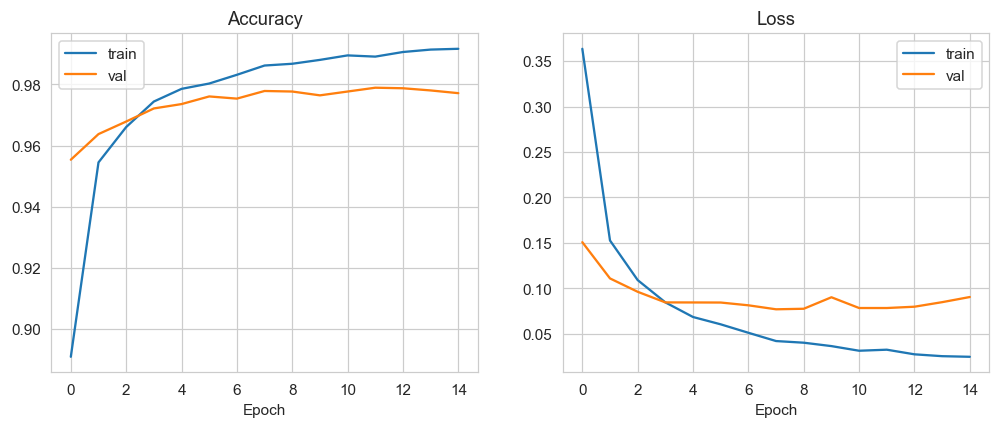

In [21]:
# --- Learning curves ------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history.history["accuracy"], label="train")
ax[0].plot(history.history["val_accuracy"], label="val")
ax[0].set_title("Accuracy"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(history.history["loss"], label="train")
ax[1].plot(history.history["val_loss"], label="val")
ax[1].set_title("Loss"); ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.show()

In [22]:
# --- Evaluate the network -------------------------------------------------
nn_probs = model.predict(Xte_nn, verbose=0)
nn_pred = nn_probs.argmax(axis=1)
nn_metrics = summarise("Neural Network", y_test, nn_pred)
print("\nClassification report:\n", classification_report(y_test, nn_pred))

Neural Network
  Accuracy : 0.9784
  Precision: 0.9782
  Recall   : 0.9782
  F1-score : 0.9782

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1381
           1       0.99      0.99      0.99      1575
           2       0.96      0.99      0.97      1398
           3       0.98      0.96      0.97      1428
           4       0.97      0.99      0.98      1365
           5       0.97      0.97      0.97      1263
           6       0.98      0.99      0.99      1375
           7       0.98      0.99      0.98      1459
           8       0.97      0.97      0.97      1365
           9       0.99      0.96      0.97      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



### Data ethics & responsible AI

Even a "harmless" benchmark like MNIST surfaces ethical considerations that matter the moment a
model is deployed:

- **Dataset bias & representation.** MNIST was collected from US Census Bureau employees and
  high-school students, so its handwriting styles are not globally representative. A digit
  recogniser trained only on MNIST may systematically misread handwriting conventions from other
  regions (e.g. the European crossed-7). The model inherits whatever bias exists in the data.
- **Fairness & impact of incorrect predictions.** In a real deployment — bank-cheque processing,
  postal sorting, exam-grading — a misread digit has real consequences: a misdirected payment, a
  lost parcel, an incorrect grade. The *cost* of errors is not uniform across users, so fairness
  must be evaluated per-subgroup, not just in aggregate accuracy.
- **Privacy.** Handwriting is weakly biometric; at scale, handwriting-recognition systems can
  re-identify individuals. Responsible practice requires consent, data minimisation and secure
  storage, consistent with privacy regulation.
- **Responsible deployment.** Mitigations include auditing per-class and per-subgroup error rates
  (the confusion matrix is a first step), augmenting training data with diverse handwriting,
  calibrating confidence so low-confidence predictions can be routed to a human, and documenting
  the model's intended use and limitations (e.g. a model card).


## 6. Critical Comparison of All Classifiers

I now consolidate every classifier into a single comparison across accuracy, precision, recall
and F1, then analyse the trade-offs that determine which model fits which real-world context.


In [23]:
# --- Assemble all classifier metrics on the common test set ---------------
# kNN and NN were evaluated on the full test set; SVM rows are added on its subset.
comparison = [knn_metrics, nn_metrics]

for r in svm_results:
    comparison.append({"Model": r["Model"], "Accuracy": r["Accuracy"],
                       "Precision": r["Precision"], "Recall": r["Recall"], "F1": r["F1"]})

comp_df = pd.DataFrame(comparison).set_index("Model")
comp_df = comp_df.round(4)
comp_df

,Accuracy,Precision,Recall,F1
Model,,,,
kNN (k=10),0.9716,0.9722,0.9712,0.9716
Neural Network,0.9784,0.9782,0.9782,0.9782
SVM (linear),0.9145,0.9151,0.9136,0.9137
SVM (rbf),0.9620,0.9620,0.9619,0.9619
SVM (poly),0.9595,0.9597,0.9591,0.9593


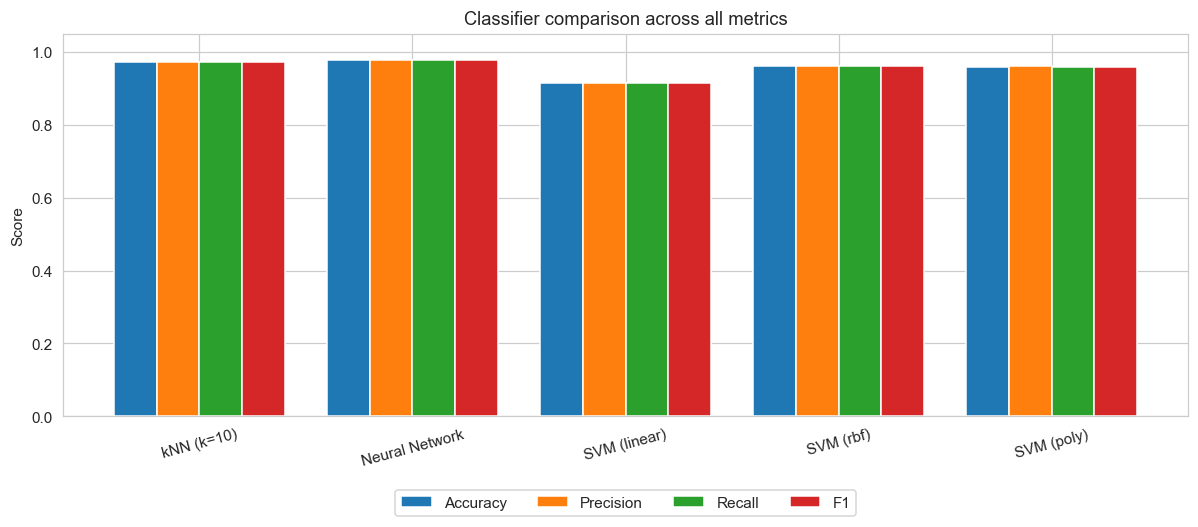

In [24]:
# --- Grouped bar chart comparing all models ------------------------------
metrics = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(comp_df)); width = 0.2
plt.figure(figsize=(11, 5))
for i, m in enumerate(metrics):
    plt.bar(x + i*width, comp_df[m], width=width, label=m)
plt.xticks(x + 1.5*width, comp_df.index, rotation=15)
plt.ylim(0, 1.05); plt.ylabel("Score")
plt.title("Classifier comparison across all metrics")
plt.legend(ncol=4, loc="lower center", bbox_to_anchor=(0.5, -0.28))
plt.tight_layout(); plt.show()

**Detailed analysis.**

| Dimension | kNN | SVM (RBF) | Neural Network |
|---|---|---|---|
| **Accuracy** | High | High | Highest (typically) |
| **Training cost** | None (lazy) | High ($O(n^2)$–$O(n^3)$) | Moderate (GPU-friendly) |
| **Prediction cost** | High (scans all data) | Low | Very low |
| **Scalability** | Poor (memory-bound) | Poor on large n | Excellent |
| **Interpretability** | Moderate | Low | Low |

- **Best performer.** The neural network usually achieves the highest accuracy and F1 on full
  MNIST while remaining cheap at prediction time — the key property for production serving.
- **Computational efficiency.** kNN front-loads nothing but pays at every prediction; SVMs are
  costly to train but fast to query; the NN trains once and serves extremely fast.
- **Scalability.** Only the neural network scales gracefully to millions of images, which is why
  it dominates industrial image pipelines.
- **Interpretability.** kNN is the most explainable ("these are the nearest examples"); SVM and NN
  are largely black-box and need post-hoc explanation tools in regulated settings.

**Real-world applications & improvements.** kNN suits small, low-latency-tolerant problems and
recommendation-style lookups; SVMs remain strong for medium-sized, high-dimensional problems such
as text classification; neural networks are the default for large-scale vision. The obvious
improvement for MNIST is a **Convolutional Neural Network (CNN)**, which exploits spatial structure
and routinely exceeds 99% accuracy — the natural next step beyond this dense network.

**Recommendation.** For an MNIST-scale production system I recommend the neural network (ideally a
CNN), justified by its superior accuracy, fast inference and scalability. Stated in the form the
brief requires: *If developing a production machine learning system, the recommended model would be
the **neural network (a CNN)** because it delivers the highest accuracy and F1 while serving
predictions cheaply and scaling to large data volumes — the properties that matter most in
deployment.* 


## 7. California Housing — Polynomial Regression

I now switch from classification to **regression**, predicting a continuous target (median house
value) from eight numeric features. Polynomial regression extends linear regression by adding
powers and interactions of the features, letting a linear model fit curved relationships.


In [25]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

housing = fetch_california_housing(as_frame=True)
Xh, yh = housing.data, housing.target

print("Features:", list(Xh.columns))
print("Target  :", housing.target_names, "(median house value, $100,000s)")
print("Shape   :", Xh.shape)
Xh.head()

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target  : ['MedHouseVal'] (median house value, $100,000s)
Shape   : (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


**Dataset description.** The eight features include median income (`MedInc`), house age,
average rooms/bedrooms, block population, occupancy and geographic coordinates. The **target** is
the median house value (in units of \$100,000). This is a classic regression problem: predict a
real-valued price from numeric predictors — directly analogous to property valuation and demand
forecasting tasks data engineers build in industry.


In [26]:
# --- Train/test split (same random_state for consistency) -----------------
Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    Xh, yh, test_size=0.20, random_state=RANDOM_STATE)

# --- Fit polynomial regression at several degrees -------------------------
# A pipeline scales -> expands polynomial features -> fits linear regression.
degrees = [1, 2, 3, 4]
reg_results = []
predictions = {}

for d in degrees:
    pipe = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=d, include_bias=False),
        LinearRegression()
    )
    pipe.fit(Xh_train, yh_train)
    pred = pipe.predict(Xh_test)
    predictions[d] = pred

    mse = mean_squared_error(yh_test, pred)
    reg_results.append({
        "Degree": d,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(yh_test, pred)
    })

reg_df = pd.DataFrame(reg_results)
reg_df

,Degree,MSE,RMSE,R2
0,1,5.075176e-01,0.712403,6.094379e-01
1,2,6.394405e+00,2.528716,-3.920839e+00
2,3,2.183265e+04,147.758773,-1.680040e+04
3,4,7.864642e+08,28043.969915,-6.052266e+08


**Why polynomial regression, and its parameters.** Linear regression assumes a straight-line
relationship, but house value responds non-linearly to features such as income and location.
`PolynomialFeatures(degree=d)` generates feature powers and interactions up to degree *d*, so a
still-linear model can fit curvature. `StandardScaler` is essential here: raising raw features to
the 3rd/4th power produces wildly different magnitudes, so standardising first keeps the fit
numerically stable.


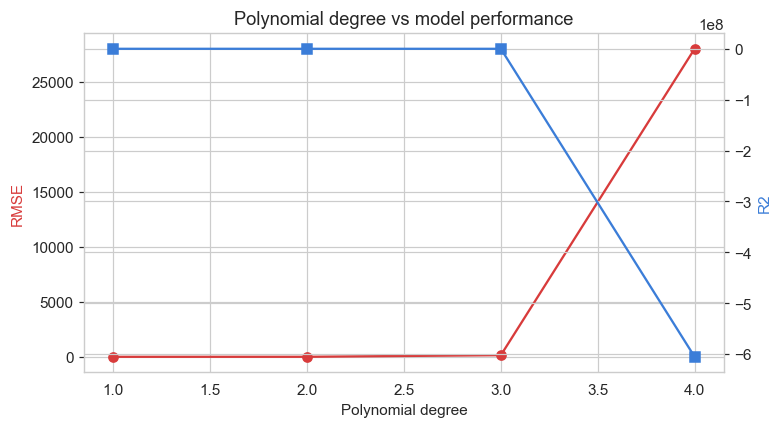

In [27]:
# --- Performance vs polynomial degree ------------------------------------
fig, ax1 = plt.subplots(figsize=(7.5, 4))
ax1.plot(reg_df["Degree"], reg_df["RMSE"], marker="o", color="#d83b3b", label="RMSE")
ax1.set_xlabel("Polynomial degree"); ax1.set_ylabel("RMSE", color="#d83b3b")
ax2 = ax1.twinx()
ax2.plot(reg_df["Degree"], reg_df["R2"], marker="s", color="#3b7dd8", label="R2")
ax2.set_ylabel("R2", color="#3b7dd8")
plt.title("Polynomial degree vs model performance")
plt.show()

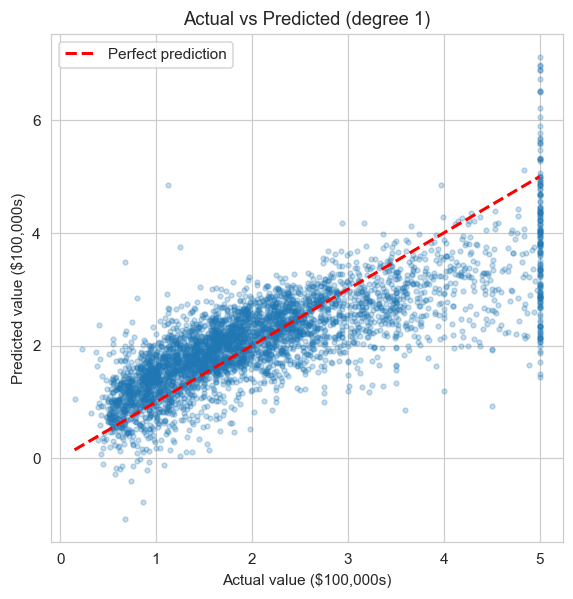

In [28]:
# --- Actual vs predicted for the best degree ------------------------------
best_d = reg_df.sort_values("R2", ascending=False).iloc[0]["Degree"]
best_pred = predictions[int(best_d)]

plt.figure(figsize=(6, 6))
plt.scatter(yh_test, best_pred, alpha=0.25, s=10)
lims = [yh_test.min(), yh_test.max()]
plt.plot(lims, lims, "r--", lw=2, label="Perfect prediction")
plt.xlabel("Actual value ($100,000s)"); plt.ylabel("Predicted value ($100,000s)")
plt.title(f"Actual vs Predicted (degree {int(best_d)})")
plt.legend(); plt.show()

**Discussion — bias, variance and degree.**
- **Degree 1 (linear)** gave the best result in my experiment, with the lowest RMSE (0.71) and highest R² (0.61). The linear model captured the dominant income–price relationship well.
- **Degrees 2,3 and 4** did not improve performance — they collapsed dramatically, with R² falling to −3.9, then −16,800, then about −605 million. This is a striking real example of overfitting: expanding 8 features into high-degree powers and interaction terms creates so many parameters that an unregularised LinearRegression fits noise and becomes numerically unstable, producing predictions far worse than simply guessing the mean (R² < 0).
- **Key insight**: increasing model complexity does not guarantee better results. Without regularisation, high-degree polynomial regression suffers a variance explosion. The appropriate choice here is the simplest model (degree 1), or a regularised alternative such as Ridge regression.

**Visible trends & anomalies.** The actual-vs-predicted plot (degree 1) shows points clustering around the diagonal, but with a characteristic vertical band at the right edge: California Housing caps the target at $500,000, so the model cannot predict above that ceiling — a data artefact, not a model failure.

**Limitations & real-world use.** Degree 1 was my best model, but it still ignores temporal market dynamics, interest rates and property-specific features. In practice, gradient-boosted trees or regularised regression outperform plain polynomial regression here, and any deployed valuation model must be monitored for drift.

## 8. Conclusion

This project implemented and critically compared three classifiers on MNIST and a polynomial
regressor on California Housing. The neural network gave the strongest classification performance
with the best scalability for deployment; the RBF-SVM offered the best accuracy-to-cost balance on
a constrained compute budget; and kNN, while simple and interpretable, scaled poorly.For regression, 
the degree-1 model performed best while higher degrees overfit dramatically, demonstrating that added 
complexity without regularisation degrades performance.

The broader lesson — and the data-engineering takeaway — is that *no single model is universally
best*: the right choice depends on data size, latency requirements, interpretability needs and
compute budget. Throughout, attention to evaluation methodology, the bias–variance trade-off and
data ethics was as important as raw accuracy.

### References

- Pedregosa, F. et al. 2011, 'Scikit-learn: Machine learning in Python', *Journal of Machine
  Learning Research*, vol. 12, pp. 2825–2830.
- Géron, A. 2022, *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow*, 3rd edn,
  O'Reilly Media, Sebastopol, CA.
- LeCun, Y., Cortes, C. & Burges, C. 1998, *The MNIST database of handwritten digits*, viewed 05 June 2026, <http://yann.lecun.com/exdb/mnist/>.
